# Reinforcement Learning

Some agent makes observations and takes actions within an environment. There are rewards within the environment, and the agent learns to take actions that have higher expected rewards

The rewards can be basically anything. Only negative rewards for taking wrong turns, only positive rewards for reaching a series of checkpoints, etc.

## Policy Gradients

The algorithm an agent uses to determine its actions is a *policy*

Example: a robot vacuum that moves forward with probability p, or randomly rotate left/right with probability 1-p. The rotation is random, between -r and +r. This is a *stochastic policy*. You want to maximize the amount of dust it picks up in some timeframe, but there are only two parameters to tweak, p and r. 
- Policy search: try every possible value of (p, r)
- Genetic algorithms: Randomly generate some number of policies, try them, kill the worst 80 policies and have the 20 survivors produce 4 offspring where an offspring is just a copy of the parent with a little variation.
- Policy gradient algorithms: evaluate the gradient of the policy and tweak its values

### Gymnasium Library

You need a simulated environment to train RL agents

In [7]:
import gymnasium as gym

env = gym.make("CartPole-v1", render_mode="rgb_array", max_episode_steps=1000)

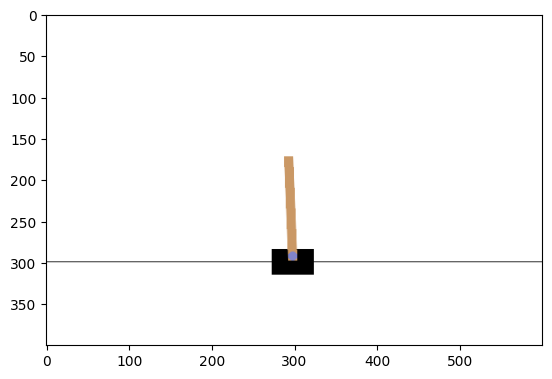

In [8]:
import matplotlib.pyplot as plt
obs, info = env.reset(seed=22)
plt.imshow(env.render())

In [9]:
env.action_space
# Possible actions are integers 0 and 1 - meaning left or right

Discrete(2)

In [10]:
obs
# here: position, velocity, pole angle, pole angular velocity

array([-0.01336531, -0.03007046, -0.04114416,  0.01531917], dtype=float32)

In [11]:
action = 0
obs, reward, done, truncated, info = env.step(action)
obs, reward

(array([-0.01396672, -0.22457895, -0.04083778,  0.294742  ], dtype=float32),
 1.0)

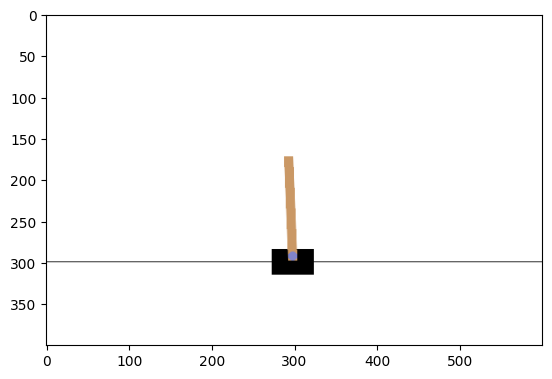

In [12]:
plt.imshow(env.render())

- Obs - the new state 
- Reward - you get 1.0 at every step, the only goal is to keep the cart running
- Done: true when episode is over
- Truncated: true when an episode is interrupted (if you set a max number of steps, here, 1000)

In [13]:
def basic_policy(obs):
    angle = obs[2]
    return 0 if angle < 0 else 1

totals = []
for episode in range(500):
    total_rewards = 0
    obs, inf = env.reset(seed=episode)
    while True:
        action = basic_policy(obs)
        obs, rew, done, trunc, info = env.step(action)
        total_rewards+=rew
        if done or trunc:
            break
    totals.append(total_rewards)

In [14]:
import numpy as np
np.mean(totals), np.std(totals), min(totals), max(totals)

(np.float64(41.698), np.float64(8.389445512070509), 24.0, 63.0)

### Neural Network Policies

We need to make a network that takes in the obs state and has one output neuron (for 0 or 1 prob). If the output probability is 70% 1, then you still sample with 30% prob 0 so the network can explore new actions while exploiting the ones that work well

There is no hidden state here but if there was it may be worth keeping info over time

In [15]:
import torch
import torch.nn as nn

class PolicyNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4,5), nn.ReLU(),
            nn.Linear(5, 1) # no sigmoid - logits instead of probabilities
        )
    
    def forward(self, state):
        return self.net(state)
    
def choose_action(model, obs):
    state = torch.as_tensor(obs)
    logit = model(state)
    dist = torch.distributions.Bernoulli(logits=logit)
    action = dist.sample()
    log_prob = dist.log_prob(action)
    return int(action.item()), log_prob

### Evaluating Actions

We don't know what the best action is at every step, so assigning credit to an action is more difficult than in past models

Common strategy: evaluate an action based on the sum of all rewards following that action, applying some discount factor gamma at every step (so it gets less credit for a reward 1000 steps away)

In [16]:
def compute_returns(rewards, discount_factor):
    returns = rewards[:]
    for step in range(len(returns) - 1, 0, -1):
        returns[step - 1] += returns[step] * discount_factor
    return torch.tensor(returns)

compute_returns([10, 0, -50], .8)
# generally, discount factor btwn .95 and .999

tensor([-22., -40., -50.])

### Solving CartPole with Policy Gradients

REINFORCE algorithm (for PG):
1) Let the neural network play the game for 1 episode, record the rewards and log probs
2) Compute each actions return
3) If an action has positive return, do it more in the future, if it has negative return, do it less

Minimize the REINFORCE loss:
$$ \mathcal{L}(\theta) = - \sum_t \log \pi_{\theta} (a_t | s_t) \cdot r_t $$
- $\pi_{\theta} (a_t | s_t)$ represents the policy networks estimated probability for some action a_t, given state s_t, 
- and r_t is the observed return of the action

In [17]:
def run_episode(model, env, seed=None):
    log_probs, rewards = [], []
    obs, info = env.reset(seed=seed)
    while True: 
        action, log_prob = choose_action(model, obs)
        obs, reward, done, truncated, _info = env.step(action)
        log_probs.append(log_prob)
        rewards.append(reward)
        if done or truncated:
            return log_probs, rewards
        
def train_reinforce(model, optimizer, env, n_episodes, discount_factor):
    for episode in range(n_episodes):
        seed = torch.randint(0, 2**32, size=()).item()
        log_probs, rewards = run_episode(model, env, seed=seed) # run the episode
        returns = compute_returns(rewards, discount_factor) 
        std_returns = (returns - returns.mean()) / (returns.std() + 1e-7) # standardize the returns for stable training
        losses = [-logp * rt for logp, rt in zip(log_probs, std_returns)] # the REINFORCE loss
        loss = torch.cat(losses).sum()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        print(f"\rEpisode {episode + 1}, Reward: {sum(rewards):.2f}", end=" ")

In [18]:
torch.manual_seed(42)
model = PolicyNetwork()
optimizer = torch.optim.NAdam(model.parameters(), lr=0.06)
train_reinforce(model, optimizer, env, n_episodes=500, discount_factor=0.99)

Episode 500, Reward: 84.00  

For better performance you can also inject human biases into the agent for performance - like adding a negative reward that scales with the pole's angle

REINFORCE works well for this example, but its too unstable generally - can forget everything over time. If it only sees vertical poles, itll forget what to do with slightly nonvertical poles after a while.

## Value-Based Methods

PG algorithms directly try and find the policy with the best rewards

Value based methods try to estimate the value, or expected return, of some state 

### Markov Decision Processes
- Markov chains: stochastic processes without memory

P(going from state s to s') -> depends only on (s, s'), not on anything else in the past

Markov decision processes: at each step, an agent can choose one of many possible actions. Transition probabilities DEPEND on the action chosen
- Some state transitions get a reward
- Agent wants to maximize reward over time

**Bellman Optimality**
- Estimate the optimal state value for any state s - the sum of all discounted future rewards, starting from state s
- If the agent acts optimally, optimal value of current state = avg reward after 1 optimal action + E(optimal value of all possible next states)

$$ V^*(s) = \max_a \sum_{s'}T(s,a,s')[R(s,a,s') + \gamma \cdot V^*(s')] $$
- $T(s,a,s')$ = transition probability from state s -> state s' (given agent chose action a)
- $R(s,a,s')$ = reward for going from s to s', given action a was chosen
- gamma is the discount factor


This gives you a value iteration algorithm - start by setting all state value estimates to 0, and iterate through 

$$ V_{k+1}(s) = \max_a \sum_{s'}T(s,a,s')[R(s,a,s') + \gamma \cdot V^*(s')]$$

for all s - V_k is the estimated value of state s at the k'th iteration

This gives the optimal state values, but not the optimal policy. So theres another algorithm to estimate optimal state-action values (Q-values, quality)

The optimal q value for state action pair (s,a) is the sum of all discounted future rewards the agent can expect starting from state s, choosing action a
$$ Q_{k+1}(s, a) = \max_a \sum_{s'}T(s,a,s')[R(s,a,s') + \gamma \cdot \max_{a'} Q_{k}(s', a')]$$



### Temporal Difference Learning
- Usually you have no idea (or the agent has no idea) what all the probabilities and rewards are before going through all the actions and states, many times to get a good probability estimate, once to know the reward

Temporal Difference (TD) algorithm : assume only the agent knows what actions and states there are, nothing more
- Use an exploration policy to explore the markov decision processes, and update the state values based on observations

$$V_{k+1}(s) = (1-\alpha)V_k(s) + \alpha (r + \gamma \cdot V_k(s'))$$
- alpha is the learning rate
- $(r + \gamma \cdot V_k(s'))$ is the TD target

Similar to SGD - reduce alpha over time to get better Q values

### Q-Learning

Watch an agent play, and improve Q value estimates until you know enough to choose actions with the highest q values

The algorithm:
$$Q(s,a) = r + \gamma \cdot \max_{a'} Q(s',a')$$
- for every state, action s,a pair, keep track of a running average of rewards r the agents gets upon choosing action a in state s + sum of discounted future rewards

In [19]:
# the q-learning algo
# first- step fumnction, execute one action and get next state + reward
def step(state, action):
    probas = transition_probabilities[state][action]
    next_state = np.random.choice([0, 1, 2], p=probas)
    reward = rewards[state][action][next_state]
    return next_state, reward

# random exploration policy
# good enough for simple examples
def exploration_policy(state):
    return np.random.choice(possible_actions[state])

alpha0 = 0.05  # initial learning rate
decay = 0.005  # learning rate decay
gamma = 0.90  # discount factor
state = 0  # initial state

for iteration in range(10_000):
    action = exploration_policy(state)
    next_state, reward = step(state, action)
    next_value = Q_values[next_state].max()  # greedy policy at the next step
    alpha = alpha0 / (1 + iteration * decay)
    Q_values[state, action] *= 1 - alpha
    Q_values[state, action] += alpha * (reward + gamma * next_value)
    state = next_state
    
# takes much longer than Q value iter algo to find optimal Q values - makes sense, we have less starting info here

NameError: name 'possible_actions' is not defined

Q Learning = off-policy algorithm (algo being trained != algo used in training)
- we use a random strategy to find the best Q values
- your real strategy is to just pick the actions with the best Q values

### Exploration Policies

$\epsilon$-greedy policy : Every step, act randomly with probability = $\epsilon$, greedily with probability $1-\epsilon$ (choose highest Q val action)
- obviously start with high randomness and become more greedy as your Q val estimates get better over time

Or, encourage uncommonly tried actions:
$$Q(s,a) = r + \gamma \cdot \max_{a'} f(Q(s',a'), N(s',a'))$$
- N just counts # times a' chosen in s'
- f(Q, N) is an exploration function 

### Approximate Q Learning, Deep Q Learning

Q Learning doesnt scale well beyond simple MDPs - simply too many states and actions in any real example
- So, find an approximate function for Q
- In the past, these approximate functions were hand-made
- Neural nets just did this better

But how do you even train a neural net (Deep Q Network, DQN) to learn Q values?
- Bellman: Know that you want Q val roughly equal to reward r after doing a in s + discounted future returns
- Use DQN on s' for all a'
- Get approx future Q val for every possible action, and pick the highest and discount it

Target Q value = $y(s,a) = r + \gamma \cdot \max_{a'} Q_{\theta}(s', a')$
- where q theta is DQN est 

### Implementation of Deep Q Learning

- Neural net takes in a state, calculates one approx Q val for every action

DQNs dont work well with continuous action spaces unless you discretize or use policy gradients

In [20]:
class DQN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(4, 32), nn.ReLU(),
                                 nn.Linear(32, 32), nn.ReLU(),
                                 nn.Linear(32, 2))

    def forward(self, state):
        return self.net(state)
    
def choose_dqn_action(model, obs, epsilon=0.0):
        if torch.rand(()) < epsilon:  # epsilon greedy policy
            return torch.randint(2, size=()).item()
        else:
            state = torch.as_tensor(obs)
            Q_values = model(state)
            return Q_values.argmax().item()  # optimal according to the DQN

# store all experiences in a replay buffer, and sample random batches for training
# this reduces within batch correlations

def sample_experiences(replay_buffer, batch_size):
    indices = torch.randint(len(replay_buffer), size=[batch_size])
    batch = [replay_buffer[index] for index in indices.tolist()]
    return [to_tensor([exp[index] for exp in batch]) for index in range(6)]
    # experience = [s, a, r, s', did_end, was_truncated]

def to_tensor(data):
    array = np.stack(data)
    dtype = torch.float32 if array.dtype == np.float64 else None
    return torch.as_tensor(array, dtype=dtype)

def play_and_record_episode(model, env, replay_buffer, epsilon, seed=None):
    obs, _info = env.reset(seed=seed)
    total_rewards = 0
    model.eval()
    with torch.no_grad():
        while True:
            action = choose_dqn_action(model, obs, epsilon)
            next_obs, reward, done, truncated, _info = env.step(action)
            experience = (obs, action, reward, next_obs, done, truncated)
            replay_buffer.append(experience)
            total_rewards += reward
            if done or truncated:
                return total_rewards
            obs = next_obs
            
def dqn_training_step(model, optimizer, criterion, replay_buffer, batch_size, discount_factor):
    experiences = sample_experiences(replay_buffer, batch_size)
    state, action, reward, next_state, done, truncated = experiences
    with torch.inference_mode():
        next_Q_value = model(next_state)

    max_next_Q_value, _ = next_Q_value.max(dim=1) # get max Q val for every experience in the batch
    running = (~(done | truncated)).float()  # 0 if s' is over (no more rewards), 1 if running
    target_Q_value = reward + running * discount_factor * max_next_Q_value
    all_Q_values = model(state)
    Q_value = all_Q_values.gather(dim=1, index=action.unsqueeze(1)) # get all q vals for current state, pick the one actually chosen
    
    loss = criterion(Q_value, target_Q_value.unsqueeze(1)) # usually just mse btwn target and predicted
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

In [21]:
from collections import deque

def train_dqn(model, env, replay_buffer, optimizer, criterion, n_episodes=800, warmup=30, batch_size=32, discount_factor=0.95):
    totals = []
    for episode in range(n_episodes):
        epsilon = max(1 - episode / 500, 0.01)
        seed = torch.randint(0, 2**32, size=()).item()
        total_rewards = play_and_record_episode(model, env, replay_buffer, epsilon, seed=seed) # play an episode 
        print(f"\rEpisode: {episode + 1}, Rewards: {total_rewards}", end=" ")
        totals.append(total_rewards)
        if episode >= warmup: # get some episodes in the buffer first
            dqn_training_step(model, optimizer, criterion, replay_buffer, batch_size, discount_factor)
    return totals

torch.manual_seed(42)
dqn = DQN()
optimizer = torch.optim.NAdam(dqn.parameters(), lr=0.03)
mse = nn.MSELoss()
replay_buffer = deque(maxlen=100_000)
totals = train_dqn(dqn, env, replay_buffer, optimizer, mse)

Episode: 800, Rewards: 1000.0 

Issue: model is both making predictions and setting targets. training will NOT be stable

### DQN Improvements

Use two DQNs instead of one for training:
- Online model: learns at each step, moves agent
- Target model: a clone of the online model taken every 10k steps, makes Q-val targets stable

Double DQN
- Target network often overestimates Q-vals because of random q-val variations and always selecting the largest q-val
- Use online model rather than target model to select best action for next state

Prioritized Experience Research:
- Samples experiences nonuniformly from buffer
- Find magnitude of TD error to estimate surprise of one experience
- But you also have to downweight the effect on the weights otherwise the model overfits


## Actor-Critic Algorithms

Combine policy gradients and value based methods

Policy: the actor, Value network: the critic

Actor uses the critic to estimate value of actions or states, to guide policy updates
- Critic uses large replay buffer to stabilize training

In [25]:
class ActorCritic(nn.Module):
    def __init__(self):
        super().__init__()
        self.body = nn.Sequential(nn.Linear(4, 32), nn.ReLU(),
                                  nn.Linear(32, 32), nn.ReLU())
        self.actor_head = nn.Linear(32, 1)  # outputs action logits
        self.critic_head = nn.Linear(32, 1)  # outputs state values

    def forward(self, state):
        features = self.body(state)
        return self.actor_head(features), self.critic_head(features)

def choose_action_and_evaluate(model, obs): # same as REINFORCE network
    state = torch.as_tensor(obs)
    logit, state_value = model(state)
    dist = torch.distributions.Bernoulli(logits=logit)
    action = dist.sample()
    log_prob = dist.log_prob(action)
    return int(action.item()), log_prob, state_value # needs to return the state value from the critic

def ac_training_step(optimizer, criterion, state_value, target_value, log_prob, critic_weight):
    td_error = target_value - state_value # td error = gap between target y = r + gamma V(s'), and state value V(s)
    actor_loss = -log_prob * td_error.detach() # error = log prob * td error, so you encourage actions that did better than value network expected
    critic_loss = criterion(state_value, target_value) # just want V(s) to match targets y (so you want td error=0)
    loss = actor_loss + critic_weight * critic_loss # generally want less weight to critic loss for stable training
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

def get_target_value(model, next_obs, reward, done, truncated, discount_factor):
    with torch.inference_mode():
        _, _, next_state_value = choose_action_and_evaluate(model, next_obs)
    running = 0.0 if (done or truncated) else 1.0
    target_value = reward + running * discount_factor * next_state_value
    return target_value

Share the same lower layers, called the body
- More efficient but less stable training
- Actor takes in batch of states and outputs 1 action logit per state

The rest of the code is just wrappers around this for training

Some ways to better stabilize Actor Critic:

**Asynchronous advantage actor-critic (A3C)** - Many agents learn in parallel and explore diff parts of environment. Each agent pushes some weight updates at some point (not all at same time) to the main network, and then pulls all the weights from that network. Also estimates advantage rather than state value

**Advantage actor-critic (A2C)** - no async updates, all model updates performed together

**Soft actor-critic (SAC)** - Learns rewards but also maximizing action entropy (being unpredictable). Encourages exploration rather than repeated actions, tends to learn far quicker

**Proximal policy optimization (PPO)** - Pased on A2C, but clips loss function so there's no huge weight updates
- Beat best DOTA 2 team in the world

Generally, SAC/PPO most popular today, PPO a good default. DQN good for discrete tasks

## Overview of popular algos

AlphaGo
- Monte carlo tree search w/ NNs to beat humans at Go
- But instead of random play like in monte carlo, uses a policy network to select moves
- In similar models, you can either include the rules of the game (dont allow the agent to make an illegal move) or dont include the game rules (estimate probability of reaching state s' from s)

Curiosity based exploration
- RL rewards are very sparse, so encourage exploration
- Agent tries to predict outcome of its actions and looks for situations where it will be surprised
- If the outcome is known/predictable, goes elsewhere
- If the outcome is unknown but agent has no control over the outcome, agent gets bored
- I.e agent gets bored of losing because it knows action y leads to losing after a while

Open ended learning (OEL)
- Train agents to endlessly learn new tasks
- Generate new and harder environments procedurally
- One agent learns one environment, but has to compete across many environments w many agents
- Only the winning agents survive